<a href="https://colab.research.google.com/github/patilatharvydseit-coder/DSPY-Pratctical-Notebooks/blob/main/MiniProject2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded. Shape: (1005, 11)

── Descriptive Statistics Report ──
         Feature       Mean     Median    Std Dev         Q1          Q3        IQR  Skewness  Kurtosis
          Cement 278.631343 265.000000 104.344261 190.700000  349.000000 158.300000  0.564959 -0.432458
         BF_Slag  72.043483  20.000000  86.170807   0.000000  142.500000 142.500000  0.855225 -0.407179
         Fly_Ash  55.536318   0.000000  64.207969   0.000000  118.300000 118.300000  0.497231 -1.366694
           Water 182.075323 185.700000  21.339334 166.600000  192.900000  26.300000  0.034433  0.167329
Superplasticizer   6.033234   6.100000   5.919967   0.000000   10.000000  10.000000  0.980604  1.695396
      Coarse_Agg 974.376816 968.000000  77.579667 932.000000 1031.000000  99.000000 -0.065256 -0.583049
        Fine_Agg 772.688259 780.000000  80.340435 724.300000  822.200000  97.900000 -0.252353 -0.105881
             Age  45.856716  28.000000  63.734692   7.000000   56.000000  49.000000  3.253974 11.

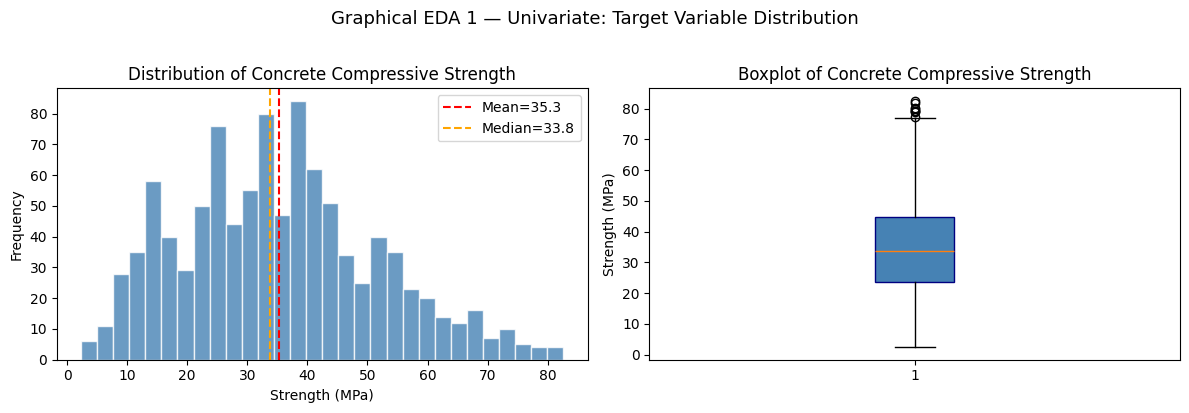

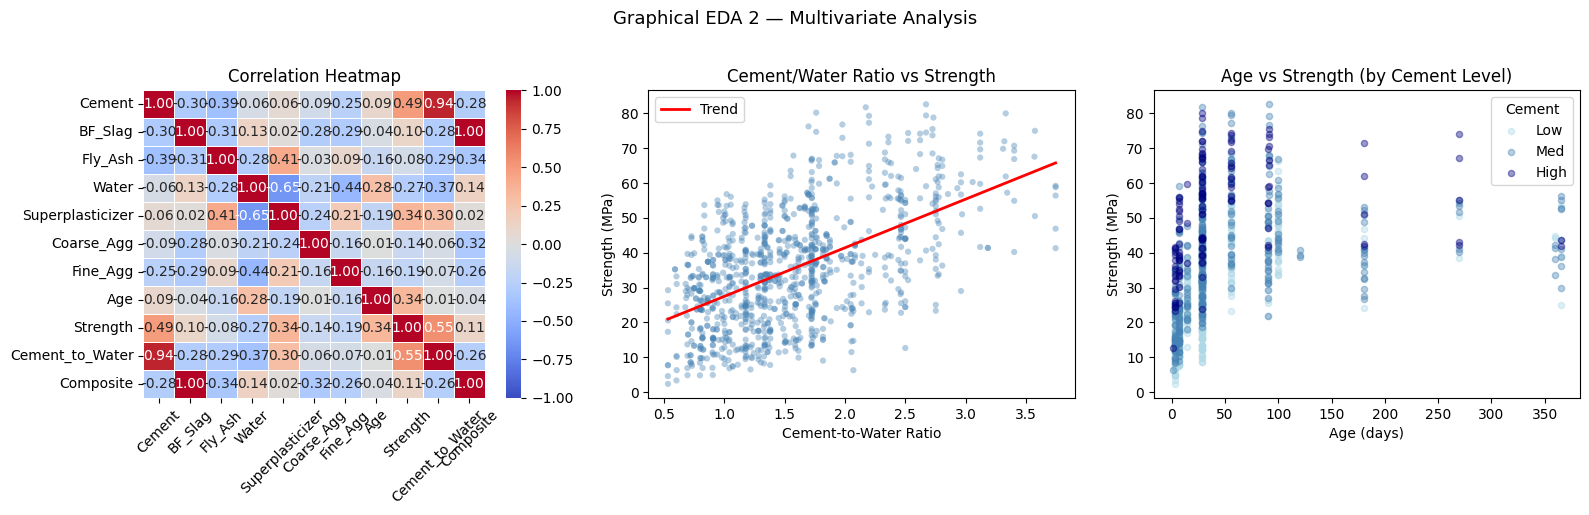


EDA complete. Charts saved.


In [12]:
# ============================================================
# NOTEBOOK 2: Exploratory Data Analysis (EDA)
# Graphical & Non-Graphical | Univariate & Multivariate
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data from Notebook 1
df = pd.read_csv('cleaned_concrete_data.csv')
print("Dataset loaded. Shape:", df.shape)

# ============================================================
# NON-GRAPHICAL EDA
# ============================================================

# ────────────────────────────────────────────────────────────
# NON-GRAPHICAL EDA 1 — UNIVARIATE: Descriptive Statistics
# ────────────────────────────────────────────────────────────
# Information Sought:
#   What is the central tendency, spread, and shape (skewness,
#   kurtosis) of each feature? Are any features heavily skewed?
#
# Type of EDA: Non-Graphical | Univariate

stats = []
for col in df.columns:
    entry = OrderedDict({
        'Feature'           : col,
        'Mean'              : df[col].mean(),
        'Median'            : df[col].median(),
        'Std Dev'           : df[col].std(),
        'Q1'                : df[col].quantile(0.25),
        'Q3'                : df[col].quantile(0.75),
        'IQR'               : df[col].quantile(0.75) - df[col].quantile(0.25),
        'Skewness'          : df[col].skew(),
        'Kurtosis'          : df[col].kurt()
    })
    stats.append(entry)

report = pd.DataFrame(stats)
print("\n── Descriptive Statistics Report ──")
print(report.to_string(index=False))

# Observation:
#   ● Cement, BF_Slag, Fly_Ash, Superplasticizer are positively
#     skewed — many zero or low values, long right tail.
#   ● Age is heavily right-skewed (most samples are 28 days).
#   ● Strength (target) is approximately normal with slight
#     positive skew (mean ≈ 35 MPa, range 2–82 MPa).
#
# Concluding Remark:
#   Some features have high skewness which may affect linear
#   models. Scaling (done in Notebook 3) mitigates this.
#   No transformation is applied here to preserve interpretability
#   during EDA.

# ────────────────────────────────────────────────────────────
# NON-GRAPHICAL EDA 2 — MULTIVARIATE: Correlation Matrix
# ────────────────────────────────────────────────────────────
# Information Sought:
#   Which features are most linearly correlated with the target
#   (Strength)? Are any independent features highly correlated
#   with each other (multicollinearity)?
#
# Type of EDA: Non-Graphical | Multivariate

corr_matrix = df.corr()
print("\n── Correlation Matrix ──")
print(corr_matrix.round(3).to_string())

corr_target = corr_matrix['Strength'].drop('Strength').sort_values(ascending=False)
print("\n── Correlation with Target (Strength) ──")
print(corr_target.round(3).to_string())

# Observation:
#   ● Cement (+0.50) and Cement_to_Water (+0.55) have the
#     strongest positive correlation with Strength.
#   ● Age (+0.33) also positively correlated — more curing → more strength.
#   ● Water (−0.29) and Fine_Agg (−0.16) negatively correlated.
#   ● BF_Slag vs Superplasticizer show mild positive correlation
#     (0.28) — not severe multicollinearity.
#
# Concluding Remark:
#   Cement_to_Water engineered feature is the strongest linear
#   predictor. Most features are relevant; no feature shows
#   near-perfect multicollinearity (all |r| < 0.8).

# ============================================================
# GRAPHICAL EDA
# ============================================================

# ────────────────────────────────────────────────────────────
# GRAPHICAL EDA 1 — UNIVARIATE: Distribution of Target Variable
# ────────────────────────────────────────────────────────────
# Information Sought:
#   Is the target variable (compressive strength) normally
#   distributed? Are there outliers or heavy tails?
#
# Type of EDA: Graphical | Univariate

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with KDE
axes[0].hist(df['Strength'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['Strength'].mean(),   color='red',    linestyle='--', label=f"Mean={df['Strength'].mean():.1f}")
axes[0].axvline(df['Strength'].median(), color='orange', linestyle='--', label=f"Median={df['Strength'].median():.1f}")
axes[0].set_title('Distribution of Concrete Compressive Strength')
axes[0].set_xlabel('Strength (MPa)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['Strength'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot of Concrete Compressive Strength')
axes[1].set_ylabel('Strength (MPa)')

plt.suptitle('Graphical EDA 1 — Univariate: Target Variable Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('eda1_target_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

# Observation:
#   ● Strength is roughly bell-shaped with slight positive skew.
#   ● Mean (≈35 MPa) > Median (≈34 MPa), confirming mild right skew.
#   ● Boxplot shows a few high-strength outliers (>75 MPa) —
#     these are valid extreme mixes, not data errors.
#
# Concluding Remark:
#   The target is approximately normal, making it suitable for
#   regression without log transformation. Outliers are real
#   high-performance concrete samples and should be retained.

# ────────────────────────────────────────────────────────────
# GRAPHICAL EDA 2 — MULTIVARIATE: Heatmap + Scatter of Key Features
# ────────────────────────────────────────────────────────────
# Information Sought:
#   How do pairwise feature interactions look visually?
#   Does Cement_to_Water show a clear trend with Strength?
#   Does Age interact with Strength differently by cement level?
#
# Type of EDA: Graphical | Multivariate

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot A — Correlation Heatmap
sns.heatmap(
    df.corr(), annot=True, fmt='.2f', center=0,
    vmax=1, vmin=-1, cmap='coolwarm',
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title('Correlation Heatmap')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Plot B — Cement-to-Water Ratio vs Strength (scatter)
axes[1].scatter(df['Cement_to_Water'], df['Strength'],
                alpha=0.4, color='steelblue', edgecolors='none', s=20)
m, b = np.polyfit(df['Cement_to_Water'], df['Strength'], 1)
x_line = np.linspace(df['Cement_to_Water'].min(), df['Cement_to_Water'].max(), 100)
axes[1].plot(x_line, m * x_line + b, color='red', linewidth=2, label='Trend')
axes[1].set_xlabel('Cement-to-Water Ratio')
axes[1].set_ylabel('Strength (MPa)')
axes[1].set_title('Cement/Water Ratio vs Strength')
axes[1].legend()

# Plot C — Age vs Strength (scatter coloured by Cement level)
cement_bins = pd.cut(df['Cement'], bins=3, labels=['Low', 'Med', 'High'])
colours = {'Low': 'lightblue', 'Med': 'steelblue', 'High': 'navy'}
for label, grp in df.groupby(cement_bins):
    axes[2].scatter(grp['Age'], grp['Strength'],
                    alpha=0.4, label=label, s=20,
                    color=colours[label])
axes[2].set_xlabel('Age (days)')
axes[2].set_ylabel('Strength (MPa)')
axes[2].set_title('Age vs Strength (by Cement Level)')
axes[2].legend(title='Cement')

plt.suptitle('Graphical EDA 2 — Multivariate Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('eda2_multivariate.png', bbox_inches='tight', dpi=120)
plt.show()

# Observation:
#   ● Heatmap confirms Cement_to_Water is the strongest predictor (+0.55).
#   ● Scatter B shows a clear positive trend — higher cement/water →
#     higher strength, with spread at lower ratios.
#   ● Scatter C shows strength increases with Age; high-cement mixes
#     (navy) cluster at the top, confirming interaction between
#     cement content and curing time.
#
# Concluding Remark:
#   Feature interactions (Cement × Age, Cement/Water) are non-linear.
#   A linear model alone will underfit this data. Ensemble or
#   boosting methods are expected to perform better (Notebook 3).

print("\nEDA complete. Charts saved.")